Using the typing dataset (lightgbm) from that was label encoded duing preprocessing

In [143]:
#Importing dependencies and modules

import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [144]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/lightbgm.csv")

In [145]:
df

,Unnamed: 0,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,0,183.6,0,339.8,199.2,False,False
1,3,0,66.4,2,250.0,171.9,True,True
2,4,1,187.5,3,234.4,31.3,True,False
3,5,1,89.8,1,226.6,113.3,False,True
4,6,1,93.8,1,460.9,367.2,True,True
...,...,...,...,...,...,...,...,...
64431,86788,0,175.8,0,31.3,113.3,True,True
64432,86790,0,78.1,0,234.4,156.3,True,True
64433,86791,0,46.9,0,515.6,453.1,True,True
64434,86792,1,85.9,1,218.8,46.9,False,False


In [146]:
#Dropping the unmaned column right away
df = df.drop(columns= "Unnamed: 0")

In [147]:
for col in df.columns:
    print(df[col].unique())

[0 1]
[1.83600e+02 6.64000e+01 1.87500e+02 8.98000e+01 9.38000e+01 1.25000e+02
 1.09400e+02 7.42000e+01 1.01600e+02 6.25000e+01 9.96000e+01 2.10900e+02
 7.03000e+01 1.68000e+02 1.40600e+02 5.47000e+01 2.03100e+02 9.77000e+01
 8.59000e+01 1.28900e+02 2.18800e+02 1.44500e+02 1.32800e+02 9.40000e+01
 2.34400e+02 7.81000e+01 1.64100e+02 1.71900e+02 1.13300e+02 8.20000e+01
 1.17200e+02 3.13000e+01 1.11300e+02 1.75800e+02 6.05000e+01 5.08000e+01
 1.56000e+01 9.57000e+01 1.21100e+02 1.52300e+02 1.30900e+02 1.63000e+02
 1.60200e+02 4.69000e+01 4.49000e+01 1.48400e+02 1.56300e+02 1.19100e+02
 1.79700e+02 1.43600e+02 1.74800e+02 0.00000e+00 1.05500e+02 2.34000e+01
 3.10500e+02 1.17000e+01 1.95300e+02 3.91000e+01 2.42200e+02 2.81300e+02
 1.36700e+02 1.64000e+02 2.07000e+02 3.71000e+01 2.42100e+02 1.26000e+02
 1.15200e+02 2.50000e+02 1.03500e+02 1.07400e+02 2.14800e+02 1.91400e+02
 1.57000e+02 4.10000e+01 1.58200e+02 1.76000e+02 1.60000e+02 3.52000e+01
 2.38300e+02 5.86000e+01 8.79000e+01 2.57800e

In [148]:
df["Parkinsons"].value_counts()

Parkinsons
False    32481
True     31955
Name: count, dtype: int64

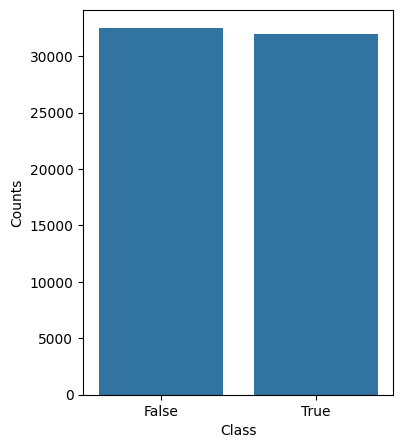

In [149]:
#Visualizations 

class_counts = np.bincount(df["Parkinsons"])

plt.figure(figsize=(4,5))
sns.barplot(x = np.unique(df["Parkinsons"]), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [150]:
#Importing modules
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [151]:
#Defining the features and labels for dataset 
y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons", "Gender_Male", "Hand", "Direction"])

In [152]:
#Oversampling the minority class in PD
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Assume X and y are your features and labels
print("Original class distribution:", Counter(y))

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, random_state=42, test_size=0.3)



Original class distribution: Counter({False: 32481, True: 31955})
Resampled class distribution: Counter({False: 31955, True: 31955})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [153]:
print(X_train.columns.tolist())

['HoldTime', 'LatencyTime', 'FlightTime']


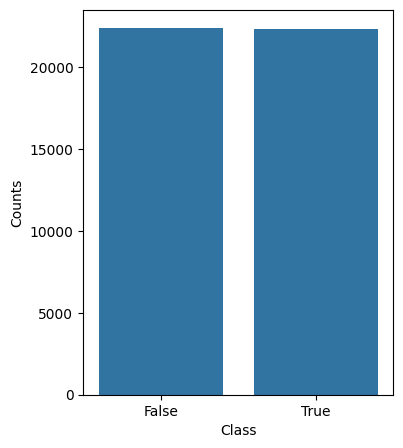

In [154]:
#Visualizations of the PD class after SMOTE
import numpy as np
class_counts = np.bincount(y_train)

plt.figure(figsize=(4, 5))
sns.barplot(x = np.unique(y_train), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [155]:
#Balancing weights

from sklearn.utils import compute_class_weight
import numpy as np

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))



In [156]:
#Defining hyperparameters in dict-like form

model_lgbm = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    class_weight = class_weight_dict,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.1)

In [157]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [158]:
#Fitting the model, training and performing evaluation

model_lgbm.fit(X_train, y_train)

model_lgbm.predict_proba(X_test)

pred = model_lgbm.predict(X_test)

score = model_lgbm.score(X_train, y_train)

acc_score = accuracy_score(y_test, pred)


In [159]:
acc_score

0.5768528660094925

In [160]:
print("Accuracy on the train set", score)

print("Accuracy on the test set", model_lgbm.score(X_test, y_test))

Accuracy on the train set 0.6052708049265708
Accuracy on the test set 0.5768528660094925


In [161]:
#Confusion matrix and classification matrix
cm = confusion_matrix(y_test, pred)
print(cm)

class_report = classification_report(y_test, pred)
print(class_report)

[[5999 3546]
 [4567 5061]]
              precision    recall  f1-score   support

       False       0.57      0.63      0.60      9545
        True       0.59      0.53      0.56      9628

    accuracy                           0.58     19173
   macro avg       0.58      0.58      0.58     19173
weighted avg       0.58      0.58      0.58     19173



<Axes: title={'center': 'Plot of feature importance'}, xlabel='Feature importance', ylabel='Features'>

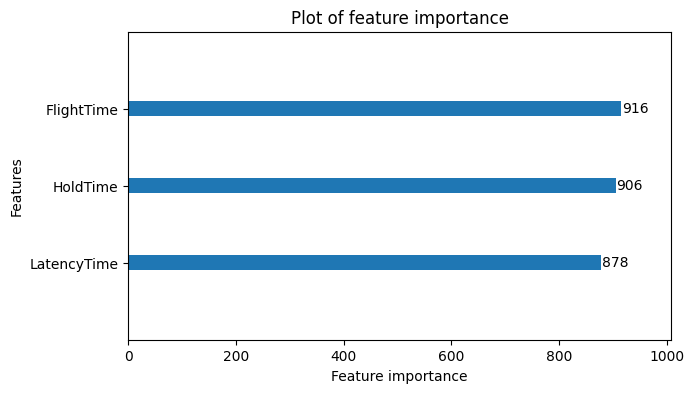

In [162]:
#Plotting important features
lgb.plot_importance(model_lgbm, title="Plot of feature importance", figsize=(7,4), grid=False )

In [163]:
model_lgbm.feature_importances_

array([906, 878, 916], dtype=int32)

Text(0.5, 1.0, 'ROC plot')

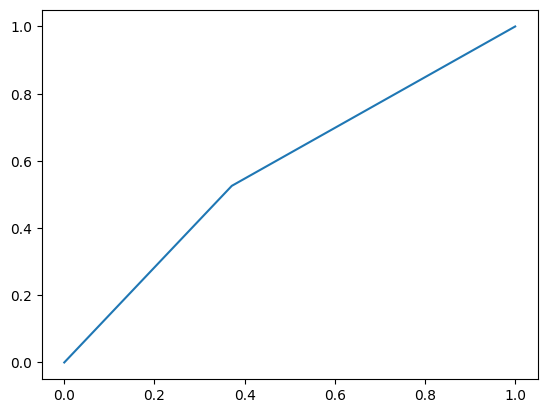

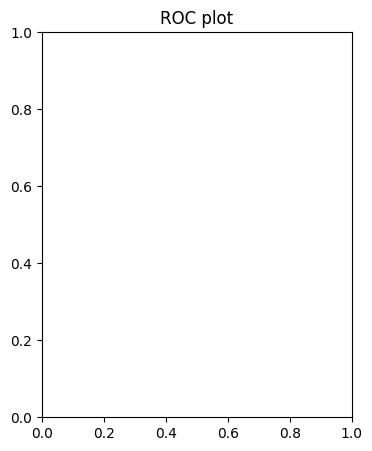

In [164]:
#Plotting roc-curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, pred)

sns.lineplot(x=fpr, y=tpr)

plt.figure(figsize=(4,5))

plt.title("ROC plot")

Retraining the model with only the most impactful features, so dropping hand and direction

In [165]:
df_new = df.drop(columns = ["Hand", "Gender_Male", "Direction"])

In [166]:
df_new

,HoldTime,LatencyTime,FlightTime,Parkinsons
0,183.6,339.8,199.2,False
1,66.4,250.0,171.9,True
2,187.5,234.4,31.3,True
3,89.8,226.6,113.3,False
4,93.8,460.9,367.2,True
...,...,...,...,...
64431,175.8,31.3,113.3,True
64432,78.1,234.4,156.3,True
64433,46.9,515.6,453.1,True
64434,85.9,218.8,46.9,False


In [167]:
#Defining labels and features, and input vectors
y_final = df_new["Parkinsons"]

X_final = df_new.drop(columns=["Parkinsons"])

X_train_new, X_test_final, y_train_new, y_test_final = train_test_split(X_final, y_final, random_state=42, test_size=0.3)

smote_final = SMOTE(random_state = 42)

X_train_final, y_train_final = smote_final.fit_resample(X_train_new, y_train_new)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [168]:
print("Train columns:", X_train_final.columns.tolist())
print("Test columns:", X_test_final.columns.tolist())

Train columns: ['HoldTime', 'LatencyTime', 'FlightTime']
Test columns: ['HoldTime', 'LatencyTime', 'FlightTime']


In [169]:
model_final = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5, verbose=-1)

In [170]:
#Fitting the model, evaluating the model, 
model_final.fit(X_train_final, y_train_final)

final_pred = model_final.predict(X_test_final)

score_final = model_final.score(X_train_final, y_train_final)


In [171]:
#Printing the evalutaion metrics
print(accuracy_score(y_test, final_pred))
print()

print(confusion_matrix(y_test, final_pred))
print()

print(classification_report(y_test, final_pred))
print()

ValueError: Found input variables with inconsistent numbers of samples: [19173, 19331]

Hyperparameter tuning with RandomizedSearchCV since the dataset is large 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold

In [ ]:
#Cross validation 
kfold = KFold(n_splits=5, random_state = 42, shuffle=True)

param_grid = {
    "num_leaves": np.arange(20,80,10).tolist(),
    "max_depth": np.arange(4, 12, 4).tolist(),
    "learning_rate": [0.01, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8,0.9],
    "bagging_fraction":[0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 50],
    "min_split_gain": [0.0, 0.01, 0.1],

}

grid = RandomizedSearchCV(estimator=model_final, param_distributions=param_grid, cv=kfold)

In [ ]:
grid.fit(X_train_final, y_train_final)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(force_col_wise=True,
                                            learning_rate=0.5, max_depth=6,
                                            num_leaves=30, objective='binary',
                                            verbose=-1),
                   param_distributions={'bagging_fraction': [0.7, 0.8, 0.9],
                                        'feature_fraction': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8],
                                        'min_child_samples': [10, 20, 50],
                                        'min_split_gain': [0.0, 0.01, 0.1],
                                        'num_leaves': [20, 30, 40, 50, 60, 70]})

In [ ]:
#Pulling the best hyperparamters

grid_best = grid.best_params_
grid.best_score_

0.5747428057110447

In [ ]:
#Training new model based on hyperparamters from RSCV

model =  lgb.LGBMClassifier(objective= "binary",
    num_leaves = grid_best["num_leaves"],
    min_split_gain = grid_best["min_split_gain"],
    min_child_samples = grid_best["min_child_samples"],
    force_col_wise = True,
    max_depth = grid_best["max_depth"],
    learning_rate = grid_best["learning_rate"],
    feature_fraction = grid_best["feature_fraction"],
    bagging_fraction = grid_best["bagging_fraction"],
    n_estimators= 100)

In [ ]:
#Fitting and making predictions on test data
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(accuracy_score(y_test, predictions))


0.5700170710258134


In [ ]:
#Confusion matrix and classification report

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[6349 3394]
 [4918 4670]]
              precision    recall  f1-score   support

       False       0.56      0.65      0.60      9743
        True       0.58      0.49      0.53      9588

    accuracy                           0.57     19331
   macro avg       0.57      0.57      0.57     19331
weighted avg       0.57      0.57      0.57     19331



Text(0.5, 1.0, 'ROC plot')

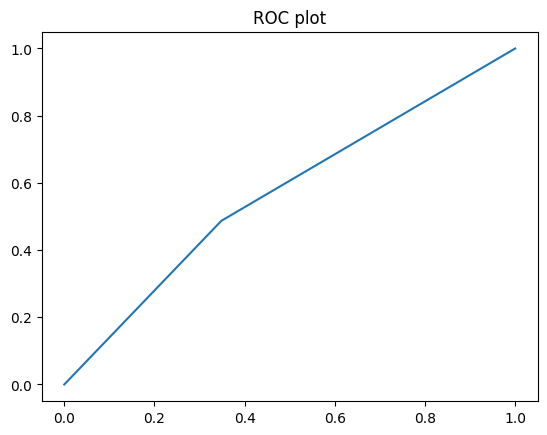

In [ ]:
#Visualizations and plotting  roc
fpr, tpr, threshold = roc_curve(y_test, predictions)

sns.lineplot(x=fpr, y=tpr,)

plt.title("ROC plot")